# 02. Термостат, распределение скоростей и флуктуации температуры

**Связь с лекцией:** NVT, контроль температуры, равномерное распределение энергии по степеням свободы. **Время:** 30–40 минут.

Идеальный газ из частиц двух масс. Частицы не взаимодействуют: термализацию обеспечивает термостат Ланжевена, а не столкновения. Координаты не ограничены; объём и давление здесь не изучаются. Мы не удаляем движение центра масс и не вводим constraints, поэтому $f=3N$.

В свободном газе нет поправки к скорости от детерминированных сил; этот выбор также упрощает интерпретацию кинетической температуры.

**Запуск:** Colab → «Среда выполнения → Выполнить все». Выбирать GPU не нужно. Все исходные системы создаются кодом; загрузка PDB и ключи доступа не требуются. Выполняйте ячейки сверху вниз. После изменения параметров повторите зависимые ячейки.

**Обозначения:** энергии в kJ/mol, длины в nm, время в ps; 1 fs = 0.001 ps.

In [ ]:
# Установка фиксированной версии: CPU достаточно, GPU не требуется.
%pip -q install openmm==8.3.1 numpy matplotlib


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import openmm as mm
from openmm import unit
from IPython.display import display, HTML
from matplotlib.animation import FuncAnimation
import platform
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True, 'font.size': 11})
rng = np.random.default_rng(2026)

backend = mm.Platform.getPlatformByName('Reference')
R = unit.MOLAR_GAS_CONSTANT_R.value_in_unit(unit.kilojoule_per_mole/unit.kelvin)
print('OpenMM', mm.__version__, '| Python', platform.python_version(), '|', backend.getName())
# Числовые единицы ниже: nm, ps, dalton, kJ/mol, K.
def vv(dt):
    it = mm.CustomIntegrator(dt*unit.picoseconds)
    it.addComputePerDof('v', 'v+0.5*dt*f/m')
    it.addComputePerDof('x', 'x+dt*v')
    it.addComputePerDof('v', 'v+0.5*dt*f/m')
    return it

def state(ctx):
    st = ctx.getState(getPositions=True, getVelocities=True, getEnergy=True)
    x = st.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
    v = st.getVelocities(asNumpy=True).value_in_unit(unit.nanometer/unit.picosecond)
    u = st.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
    return x, v, u

def movie(frames, title='', bonds=(), interval=60):
    """Небольшая XY-проекция. Показанные траектории могут быть трёхмерными."""
    a = np.asarray(frames)[::max(1, len(frames)//100)]
    fig, ax = plt.subplots(figsize=(5, 4))
    lo=a[:,:,:2].min(axis=(0,1)); hi=a[:,:,:2].max(axis=(0,1))
    pad=max(float(np.max(hi-lo))*0.15,0.1)
    ax.set(xlim=(lo[0]-pad,hi[0]+pad),ylim=(lo[1]-pad,hi[1]+pad),
           xlabel='x, nm',ylabel='y, nm',title=title,aspect='equal')
    dots=ax.scatter(a[0,:,0],a[0,:,1],s=45,c=np.arange(a.shape[1]),cmap='viridis')
    lines=[ax.plot([],[],color='gray')[0] for _ in bonds]
    def update(i):
        dots.set_offsets(a[i,:,:2])
        for line,(j,k) in zip(lines,bonds): line.set_data(a[i,[j,k],0],a[i,[j,k],1])
        return [dots]+lines
    ani=FuncAnimation(fig,update,frames=len(a),interval=interval,blit=True)
    html=ani.to_jshtml(); plt.close(fig); display(HTML(html))


OpenMM 8.3.1 | Python 3.13.15 | Reference


## Нагрев и коэффициент трения

Сначала сравниваем релаксацию от 100 K к 300 K. Значение γ задаётся в ps⁻¹.

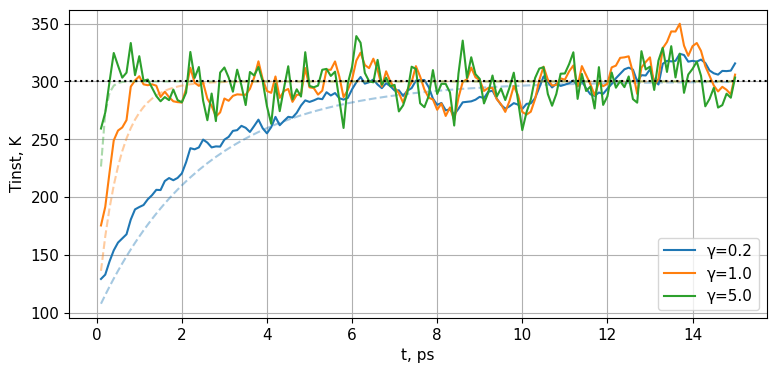

Пунктир: ожидаемая средняя релаксация свободных частиц, а не отдельная траектория.


In [5]:
N,T,dt=256,300.0,0.01
masses=np.r_[np.full(N//2,12.),np.full(N//2,48.)]
def gas(gamma,steps=1500,sample=10):
    sys=mm.System()
    for m in masses: sys.addParticle(m)
    it=mm.LangevinMiddleIntegrator(T,gamma,dt); it.setRandomNumberSeed(2026)
    ctx=mm.Context(sys,it,backend); ctx.setPositions(np.zeros((N,3)))
    ctx.setVelocitiesToTemperature(100*unit.kelvin,2026)
    temps=[]; velocities=[]
    for j in range(steps//sample):
        it.step(sample); x,v,u=state(ctx)
        temps.append(np.sum(masses[:,None]*v*v)/(3*N*R)); velocities.append(v)
    del ctx,it
    return np.arange(1,len(temps)+1)*sample*dt,np.array(temps),np.array(velocities)
fig,ax=plt.subplots()
for gamma in [0.2,1.,5.]:
    t,temp,_=gas(gamma)
    ax.plot(t,temp,label=f'γ={gamma}')
    ax.plot(t,T+(100-T)*np.exp(-2*gamma*t),'--',alpha=.4,color=ax.lines[-1].get_color())
ax.axhline(T,color='black',ls=':'); ax.set(xlabel='t, ps',ylabel='Tinst, K'); ax.legend(); plt.show()
print('Пунктир: ожидаемая средняя релаксация свободных частиц, а не отдельная траектория.')


## Компоненты скорости и модуль скорости

$v_x$ имеет нормальное распределение с дисперсией $RT/m$ в используемых молярных единицах. Модуль скорости имеет распределение Максвелла. Усреднение берётся только после начального прогрева.

m= 12.0  измеренная/теоретическая <vx²>: 0.999
m= 48.0  измеренная/теоретическая <vx²>: 1.006


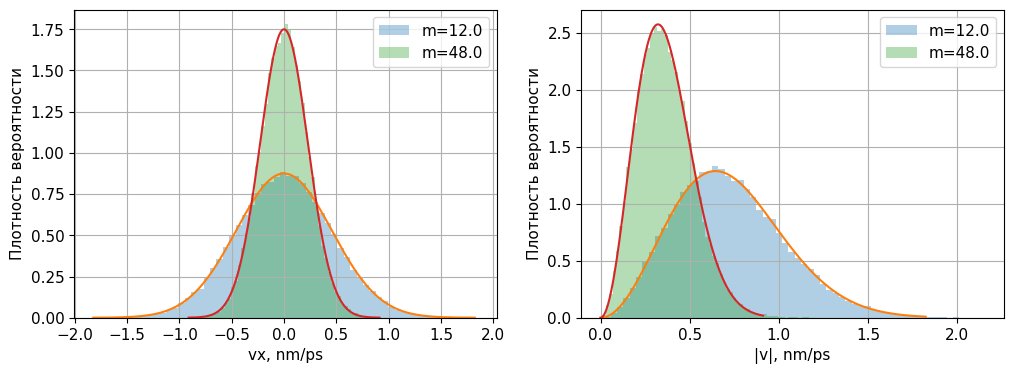

Средняя T: 299.5259292956246


In [6]:
t,temp,vel=gas(2.,steps=6000,sample=10)
eq=vel[len(vel)//3:]
fig,ax=plt.subplots(1,2,figsize=(12,4))
for sl,m in [(slice(0,N//2),12.),(slice(N//2,None),48.)]:
    vx=eq[:,sl,0].ravel(); speed=np.linalg.norm(eq[:,sl,:],axis=-1).ravel()
    sig=np.sqrt(R*T/m); x=np.linspace(-4*sig,4*sig,200); s=np.linspace(0,4*sig,200)
    ax[0].hist(vx,bins=60,density=True,alpha=.35,label=f'm={m}')
    ax[0].plot(x,np.exp(-x*x/(2*sig*sig))/(np.sqrt(2*np.pi)*sig))
    ax[1].hist(speed,bins=60,density=True,alpha=.35,label=f'm={m}')
    ax[1].plot(s,np.sqrt(2/np.pi)*s*s/sig**3*np.exp(-s*s/(2*sig*sig)))
    ratio=np.mean(vx*vx)/(R*T/m)
    print('m=',m,' измеренная/теоретическая <vx²>:',round(ratio,3))
    assert abs(ratio-1)<.15
for a in ax: a.legend(); a.set_ylabel('Плотность вероятности')
ax[0].set_xlabel('vx, nm/ps'); ax[1].set_xlabel('|v|, nm/ps'); plt.show()
print('Средняя T:',temp[len(temp)//3:].mean())


## Берендсен vs Ланжевен: правильная средняя T ещё не означает NVT.

Берендсен может правильно воспроизводить среднюю температуру, но подавляет флуктуации кинетической энергии — поэтому ансамбль неканонический.

Berendsen : <T> = 300.00 K; σ(T) = 0.000 K; Var(K)/Varканон = 1.08e-29
Langevin  : <T> = 297.88 K; σ(T) = 21.861 K; Var(K)/Varканон = 1.02


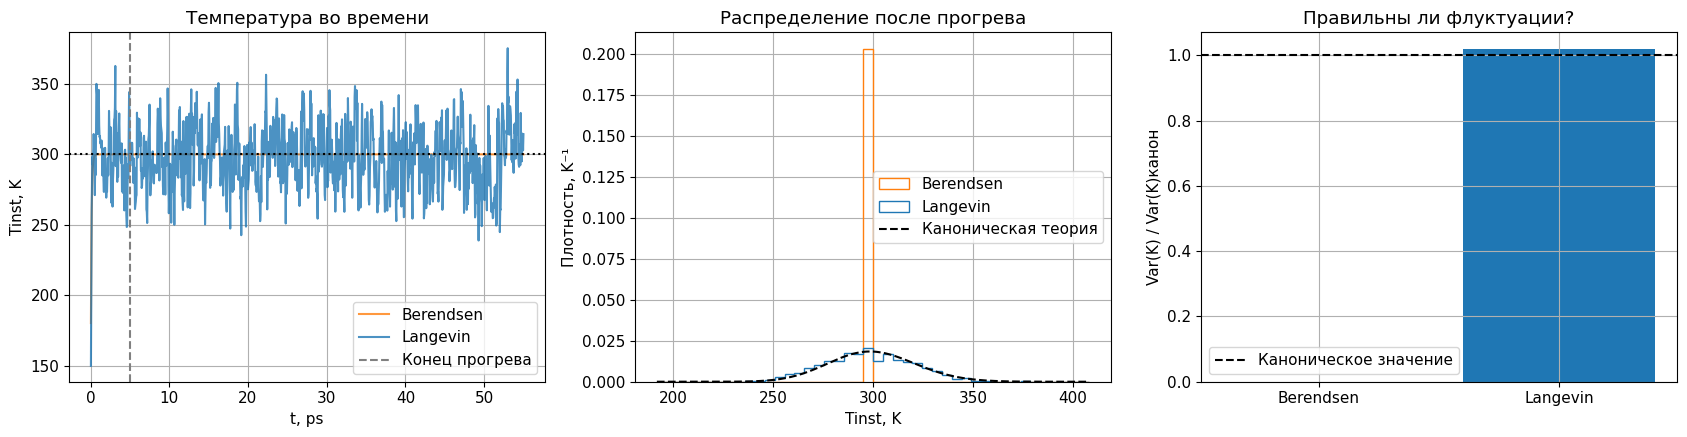


Каноническая теория: <T> = 300.0 K; σ(T) = 21.651 K


In [9]:
from math import lgamma

N_demo = 128
T_target = 300.0       # K
mass_demo = 40.0       # dalton
ndof = 3 * N_demo      # Нет constraints и удаления движения центра масс

dt_demo = 0.005        # ps
tau_B = 0.1           # ps: время связи Берендсена
gamma_L = 5.0         # ps^-1: трение Ланжевена
warmup_ps = 5.0
production_ps = 50.0
stride = 10           # Интервал сохранения, шаги

R_demo = unit.MOLAR_GAS_CONSTANT_R.value_in_unit(
    unit.kilojoule_per_mole / unit.kelvin
)
K_target = 0.5 * ndof * R_demo * T_target

assert 0 < dt_demo < tau_B

# Одинаковые начальные скорости для обоих расчётов.
# Однократное масштабирование задаёт начальную температуру ровно 100 K.
rng_demo = np.random.default_rng(2026)
v_initial = rng_demo.normal(size=(N_demo, 3))
T_initial = mass_demo * np.sum(v_initial**2) / (ndof * R_demo)
v_initial *= np.sqrt(100.0 / T_initial)


def run_thermostat_demo(kind):
    system = mm.System()
    for _ in range(N_demo):
        system.addParticle(mass_demo)

    # Частицы свободные: потенциальная энергия и силы равны нулю.
    if kind == "Berendsen":
        integrator = mm.CustomIntegrator(
            dt_demo * unit.picoseconds
        )
        integrator.addGlobalVariable("tauB", tau_B)
        integrator.addGlobalVariable("Ktarget", K_target)
        integrator.addGlobalVariable("Kcurrent", 0)
        integrator.addGlobalVariable("scaleB", 1)

        integrator.addComputePerDof("x", "x+dt*v")
        integrator.addComputeSum("Kcurrent", "0.5*m*v*v")

        # lambda² = 1 + dt/tauB * (Ttarget/Tinstant - 1)
        # При фиксированном числе степеней свободы Ttarget/T = Ktarget/K.
        integrator.addComputeGlobal(
            "scaleB",
            "sqrt(1+dt/tauB*(Ktarget/Kcurrent-1))"
        )
        integrator.addComputePerDof("v", "scaleB*v")

    else:
        integrator = mm.LangevinMiddleIntegrator(
            T_target * unit.kelvin,
            gamma_L / unit.picosecond,
            dt_demo * unit.picoseconds
        )
        integrator.setRandomNumberSeed(2026)

    context = mm.Context(
        system, integrator,
        mm.Platform.getPlatformByName("Reference")
    )
    context.setPositions(
        np.zeros((N_demo, 3)) * unit.nanometer
    )
    context.setVelocities(
        v_initial * unit.nanometer / unit.picosecond
    )

    times, kinetic = [], []
    nblocks = round(
        (warmup_ps + production_ps) / (stride * dt_demo)
    )

    for j in range(nblocks):
        integrator.step(stride)

        velocities = (
            context.getState(getVelocities=True)
            .getVelocities(asNumpy=True)
            .value_in_unit(unit.nanometer / unit.picosecond)
        )

        times.append((j + 1) * stride * dt_demo)
        kinetic.append(
            0.5 * mass_demo * np.sum(velocities**2)
        )

    del context, integrator
    return np.array(times), np.array(kinetic)


results_demo = {
    name: run_thermostat_demo(name)
    for name in ["Berendsen", "Langevin"]
}

# Канонические предсказания
var_K_theory = 0.5 * ndof * (R_demo * T_target)**2
sigma_T_theory = T_target * np.sqrt(2 / ndof)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
colors = {"Berendsen": "tab:orange", "Langevin": "tab:blue"}
T_eq, variance_ratios = {}, []

for name, (times, kinetic) in results_demo.items():
    temperatures = 2 * kinetic / (ndof * R_demo)
    equilibrium = times > warmup_ps

    T_eq[name] = temperatures[equilibrium]
    K_eq = kinetic[equilibrium]
    variance_ratios.append(
        np.var(K_eq, ddof=1) / var_K_theory
    )

    axes[0].plot(
        times, temperatures, color=colors[name],
        label=name, alpha=0.8
    )

    print(
        f"{name:10s}: "
        f"<T> = {T_eq[name].mean():.2f} K; "
        f"σ(T) = {T_eq[name].std(ddof=1):.3f} K; "
        f"Var(K)/Varканон = {variance_ratios[-1]:.3g}"
    )

# 1. Температура во времени
axes[0].axhline(T_target, color="black", ls=":")
axes[0].axvline(
    warmup_ps, color="gray", ls="--", label="Конец прогрева"
)
axes[0].set(
    xlabel="t, ps", ylabel="Tinst, K",
    title="Температура во времени"
)
axes[0].legend()

# 2. Распределение мгновенной температуры
bins = np.linspace(
    T_target - 5 * sigma_T_theory,
    T_target + 5 * sigma_T_theory,
    45
)
for name in results_demo:
    axes[1].hist(
        T_eq[name], bins=bins, density=True,
        histtype="step", lw=2,
        color=colors[name], label=name
    )

# Точное каноническое распределение Tinst — гамма-распределение.
# shape = f/2; scale = 2*Ttarget/f.
shape = ndof / 2
scale = T_target / shape
T_grid = np.linspace(bins[0], bins[-1], 500)
log_density = (
    (shape - 1) * np.log(T_grid)
    - T_grid / scale
    - lgamma(shape)
    - shape * np.log(scale)
)
axes[1].plot(
    T_grid, np.exp(log_density), "k--",
    label="Каноническая теория"
)
axes[1].set(
    xlabel="Tinst, K", ylabel="Плотность, K⁻¹",
    title="Распределение после прогрева"
)
axes[1].legend()

# 3. Количественная проверка флуктуаций
axes[2].bar(
    list(results_demo), variance_ratios,
    color=[colors[name] for name in results_demo]
)
axes[2].axhline(
    1, color="black", ls="--", label="Каноническое значение"
)
axes[2].set(
    ylabel="Var(K) / Var(K)канон",
    title="Правильны ли флуктуации?"
)
axes[2].legend()

plt.tight_layout()
plt.show()

print(
    f"\nКаноническая теория: "
    f"<T> = {T_target:.1f} K; σ(T) = {sigma_T_theory:.3f} K"
)

## Почему термостат Берендсена не создаёт канонический ансамбль?

Правильная средняя температура ещё не означает правильный термодинамический ансамбль. В каноническом ансамбле система обменивается энергией с термостатом, поэтому её кинетическая энергия флуктуирует. Термостат должен воспроизводить не только среднее значение, но и распределение этих флуктуаций.

В этом примере сравниваются термостаты Берендсена и Ланжевена для невзаимодействующих частиц. Ограничений связей и удаления движения центра масс нет, поэтому число кинетических степеней свободы равно

$$
f=3N.
$$

### 1. От распределения скоростей к флуктуациям кинетической энергии

Обозначим заданную температуру термостата через $T_0$. Для каждой независимой декартовой компоненты скорости каноническое распределение имеет вид

$$
p(v_i)=
\sqrt{\frac{m_i}{2\pi k_{\mathrm B}T_0}}
\exp\left(-\frac{m_i v_i^2}{2k_{\mathrm B}T_0}\right).
$$

Введём безразмерные скорости

$$
z_i=\sqrt{\frac{m_i}{k_{\mathrm B}T_0}}\,v_i.
$$

Тогда $z_i$ — независимые стандартные нормальные случайные величины:

$$
\langle z_i\rangle=0,\qquad
\langle z_i^2\rangle=1,\qquad
\langle z_i^4\rangle=3.
$$

Полная кинетическая энергия равна

$$
K=\sum_{i=1}^{f}\frac{m_i v_i^2}{2}
=\frac{k_{\mathrm B}T_0}{2}\sum_{i=1}^{f}z_i^2.
$$

Отсюда её среднее значение:

$$
\langle K\rangle
=\frac{k_{\mathrm B}T_0}{2}
\sum_{i=1}^{f}\langle z_i^2\rangle
=\frac{f}{2}k_{\mathrm B}T_0.
$$

Чтобы получить дисперсию, сначала найдём дисперсию квадрата одной нормальной величины:

$$
\operatorname{Var}(z_i^2)
=\langle z_i^4\rangle-\langle z_i^2\rangle^2
=3-1=2.
$$

Поскольку степени свободы независимы, дисперсии их вкладов складываются:

$$
\begin{aligned}
\operatorname{Var}(K)
&=\left(\frac{k_{\mathrm B}T_0}{2}\right)^2
\operatorname{Var}\left(\sum_{i=1}^{f}z_i^2\right)\\
&=\left(\frac{k_{\mathrm B}T_0}{2}\right)^2
\sum_{i=1}^{f}\operatorname{Var}(z_i^2)\\
&=\frac{f}{2}(k_{\mathrm B}T_0)^2.
\end{aligned}
$$

Таким образом, в каноническом ансамбле

$$
\boxed{
\langle K\rangle=\frac{f}{2}k_{\mathrm B}T_0,
\qquad
\operatorname{Var}(K)=\frac{f}{2}(k_{\mathrm B}T_0)^2.
}
$$

### 2. Флуктуации мгновенной кинетической температуры

Мгновенную кинетическую температуру определяют через текущую кинетическую энергию:

$$
T_{\mathrm{inst}}=\frac{2K}{f k_{\mathrm B}}.
$$

Это оценка температуры по конечному числу скоростей, а не изменяющаяся температура самого термостата.

Её среднее значение:

$$
\langle T_{\mathrm{inst}}\rangle
=\frac{2}{f k_{\mathrm B}}\langle K\rangle
=T_0.
$$

При умножении случайной величины на константу её дисперсия умножается на квадрат этой константы. Поэтому

$$
\begin{aligned}
\operatorname{Var}(T_{\mathrm{inst}})
&=\left(\frac{2}{f k_{\mathrm B}}\right)^2
\operatorname{Var}(K)\\
&=\frac{4}{f^2 k_{\mathrm B}^2}
\frac{f}{2}(k_{\mathrm B}T_0)^2\\
&=\frac{2T_0^2}{f}.
\end{aligned}
$$

Следовательно,

$$
\boxed{\sigma_T=T_0\sqrt{\frac{2}{f}}}
\qquad\text{и}\qquad
\boxed{\frac{\sigma_T}{T_0}=\sqrt{\frac{2}{f}}}.
$$

Для $N=128$ свободных частиц имеем $f=384$. При $T_0=300$ K:

$$
\sigma_T
=300\sqrt{\frac{2}{384}}
\approx 21.65\ \mathrm{K}.
$$

Такие колебания мгновенной температуры нормальны. Их относительная величина уменьшается как $N^{-1/2}$.

**Единицы в коде.** OpenMM использует молярные энергии в kJ/mol. При такой записи вместо $k_{\mathrm B}$ используется газовая постоянная $R$:

$$
\langle K\rangle=\frac{f}{2}RT_0,\qquad
\operatorname{Var}(K)=\frac{f}{2}(RT_0)^2,\qquad
T_{\mathrm{inst}}=\frac{2K}{fR}.
$$

Выражение для $\sigma_T$ остаётся прежним.

### 3. Как выглядит полное распределение температуры?

Сумма квадратов $f$ независимых стандартных нормальных величин имеет распределение хи-квадрат:

$$
\frac{2K}{k_{\mathrm B}T_0}\sim\chi_f^2.
$$

Следовательно,

$$
\frac{fT_{\mathrm{inst}}}{T_0}\sim\chi_f^2.
$$

Эквивалентно, мгновенная температура имеет гамма-распределение с параметрами

$$
a=\frac{f}{2},
\qquad
\theta=\frac{2T_0}{f}.
$$

Его плотность:

$$
p(T_{\mathrm{inst}})
=
\frac{T_{\mathrm{inst}}^{a-1}
\exp(-T_{\mathrm{inst}}/\theta)}
{\Gamma(a)\theta^a},
\qquad T_{\mathrm{inst}}>0.
$$

Именно эта функция показана на графике как «Каноническая теория». При большом $f$ распределение приближается к нормальному со средним $T_0$ и дисперсией $2T_0^2/f$.

### 4. Что делает термостат Берендсена?

Термостат Берендсена масштабирует все скорости на один коэффициент:

$$
\mathbf v_i'=\lambda\mathbf v_i,
$$

где

$$
\lambda^2
=1+\frac{\Delta t}{\tau_B}
\left(\frac{T_0}{T_{\mathrm{inst}}}-1\right).
$$

Здесь $\tau_B$ — параметр связи с термостатом. Поскольку кинетическая энергия квадратична по скоростям,

$$
K'=\lambda^2K.
$$

Обозначим целевую кинетическую энергию через

$$
K_0=\frac{f}{2}k_{\mathrm B}T_0.
$$

Используя $T_0/T_{\mathrm{inst}}=K_0/K$, получаем

$$
\begin{aligned}
K'
&=K\left[
1+\frac{\Delta t}{\tau_B}
\left(\frac{K_0}{K}-1\right)
\right]\\
&=K+\frac{\Delta t}{\tau_B}(K_0-K).
\end{aligned}
$$

В нашем идеальном газе сил нет: между масштабированиями кинетическая энергия не меняется. Поэтому

$$
K_{n+1}-K_0
=\left(1-\frac{\Delta t}{\tau_B}\right)(K_n-K_0),
$$

и после $n$ шагов

$$
K_n-K_0
=\left(1-\frac{\Delta t}{\tau_B}\right)^n
(K_{\mathrm{init}}-K_0).
$$

При выбранном в коде условии $0<\Delta t<\tau_B$ отклонение монотонно затухает. При малом шаге:

$$
K(t)-K_0\approx
(K_{\mathrm{init}}-K_0)e^{-t/\tau_B}.
$$

В результате $T_{\mathrm{inst}}$ стремится к $T_0$, но равновесные флуктуации в этой модели практически исчезают:

$$
\operatorname{Var}(K)\longrightarrow 0.
$$

Это противоречит каноническому предсказанию

$$
\operatorname{Var}(K)=\frac{f}{2}(k_{\mathrm B}T_0)^2>0.
$$

**Поэтому идеально ровная температура здесь является признаком неправильного ансамбля, а не более качественного термостатирования.**

В системе со взаимодействиями кинетическая и потенциальная энергии обмениваются, поэтому флуктуации при Берендсене обычно не исчезают полностью. Однако их распределение остаётся искажённым. Нулевая дисперсия — особенно наглядный предельный случай свободных частиц.

### 5. Что должно получиться при сравнении с Ланжевеном?

Термостат Ланжевена сочетает трение со случайной силой. При корректном соотношении их интенсивностей непрерывная динамика имеет каноническое стационарное распределение. Для свободных частиц используемая схема воспроизводит соответствующий процесс релаксации скоростей.

После прогрева ожидаем:

- **Берендсен:** средняя температура близка к $T_0$, но распределение слишком узкое.
- **Ланжевен:** средняя температура близка к $T_0$, а ширина распределения согласуется с каноническим предсказанием.
- **Количественный критерий:**

$$
Q=
\frac{\operatorname{Var}(K)_{\mathrm{измеренная}}}
{\frac{f}{2}(RT_0)^2}.
$$

Для канонической выборки ожидается $Q\approx1$. В данном примере с Берендсеном получаем $Q\approx0$.

### 6. Как интерпретировать конечную траекторию?

Формула для $\sigma_T$ описывает ширину равновесного распределения мгновенных температур, а не ошибку оценки средней температуры.

Соседние кадры траектории коррелированы. Поэтому статистическая ошибка среднего определяется числом эффективно независимых измерений $M_{\mathrm{eff}}$:

$$
\operatorname{SE}(\overline T)
\approx\frac{\sigma_T}{\sqrt{M_{\mathrm{eff}}}}.
$$

Обычно $M_{\mathrm{eff}}$ меньше числа сохранённых кадров. Небольшое отличие среднего от 300 K в конечной траектории Ланжевена само по себе не означает неправильный ансамбль.

## Самостоятельная работа

1. Измените массы в четыре раза. Как изменяется ширина распределения скоростей?
2. Почему T(t) не обязана совпадать с температурой термостата в каждый момент?
3. Увеличьте γ: меняется ли равновесное распределение или только скорость потери памяти?

**Ориентиры:** ширина уменьшается вдвое; конечная система флуктуирует; распределение сохраняется при корректном шаге, динамические корреляции меняются.

## Источники и границы модели

[OpenMM: интеграторы](https://docs.openmm.org/latest/userguide/theory/04_integrators.html).

Ноутбук — учебный численный эксперимент, а не валидированная параметризация реального вещества. Случайные числа имеют фиксированное начальное состояние; результаты могут немного зависеть от платформы и версии.